# Generalising the mosaic framework: tile schemes beyond the diamond

The mosaic pipeline of this repository renders greyscale images with **diamond-shaped
still-life tiles** glued together by pond frames. This notebook asks — and answers —
the natural question: *is the diamond essential, or can other shapes be linked together
in the same way to emulate a greyscale picture?*

The answer is that the diamond is just one instance of a general **tile scheme**:
a support shape on a translation lattice, a forced-alive *frame*, and automatically
derived forced-dead *interlock cells*. The composition theorem that guarantees every
diamond mosaic is a global still life carries over verbatim. We make this precise,
implement it (`gol_mosaics.tile_scheme`), validate the abstraction by re-deriving the
diamond geometry *exactly*, and then design a genuinely new family — **axis-aligned
square tiles bordered by rings of ponds** — and take it all the way to a greyscale
image mosaic that is verified to be a global still life.

Walk-through:

1. What makes the diamond mosaic work (the composition conditions)
2. The `TileScheme` abstraction and its generic interlock derivation
3. Validation: the diamond as a scheme instance
4. A new instance: pond-frame squares — including the instability that shapes its design
5. Enumerating the new tile family with the unchanged SAT machinery
6. Composability in action (positive and negative controls)
7. Emulating a greyscale picture with square tiles
8. The scheme zoo: where to go next

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Import gol_mosaics (installed with: pip install -e .); fall back to ../src
# so the notebook also runs from a plain checkout.
try:
    import gol_mosaics
except ImportError:
    sys.path.insert(0, str(Path.cwd().parent / "src"))

from gol_mosaics import tile_domain, tile_scheme
from gol_mosaics.life import is_still_life, life_step
from gol_mosaics.tile_scheme import (
    TileScheme, derive_interlock, build_scheme_domain, enumerate_scheme_tiles,
    assemble, frame_mosaic, check_frame_mosaic,
    diamond_scheme, pond_square_scheme, dead_moat_square_scheme,
)

plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm",
                     "figure.dpi": 110})

def show_grid(ax, grid, title=None):
    ax.imshow(grid, cmap="binary", interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=9)

## 1. What makes the diamond mosaic work

Every tile of the diamond family satisfies four axioms (the paper's (T1)–(T4)): it is a
still life of the rule, D4-symmetric, its border ring of ponds (the **frame**) is alive,
and a small derived set of **interlock cells** is dead. The *composition theorem* then
says: any assignment of such tiles to the lattice yields a **global** still life,
provided one global hypothesis **(H)** holds — *the frame-only mosaic (every tile
reduced to its bare frame) is itself a still life*.

The proof needs nothing diamond-specific. Abstractly, a **tile scheme** is:

* **(S1)** a support shape $A$ (which cells of the $n\times n$ tile may be alive),
  placed at every integer combination $a\,\vec u + b\,\vec v$ of two lattice basis
  vectors;
* **(S2)** a forced-alive frame $F \subseteq A$, plus forced-dead interlock cells
  derived morphologically from the geometry:
  $$E \;=\; \mathrm{free}(A)\;\cap\;\delta\bigl(\delta(A)\cap\delta(B)\bigr),$$
  where $B$ is the union of $A$ at all neighbouring lattice offsets and $\delta$ is the
  3×3 (Chebyshev-1) dilation — "free cells that influence any cell influenced by two
  tiles";
* **(S3)** consistency on overlaps: wherever two tile supports overlap, all tiles force
  the overlapped cells to the same value. (The recipe in (S2) guarantees this
  automatically for free cells — they land in $E$ — so only frames must agree.)

Under (S1)–(S3) and (H), the theorem's case analysis goes through unchanged: a cell
whose 3×3 neighbourhood meets **one** tile is covered by that tile's own still-life
constraints; a cell whose neighbourhood meets **several** tiles sees only forced cells,
and that configuration equals the frame-only mosaic — a still life by (H).

The whole diamond-specific content of the pipeline is the *instantiation* of
(S1)–(S2). Let's look at it.

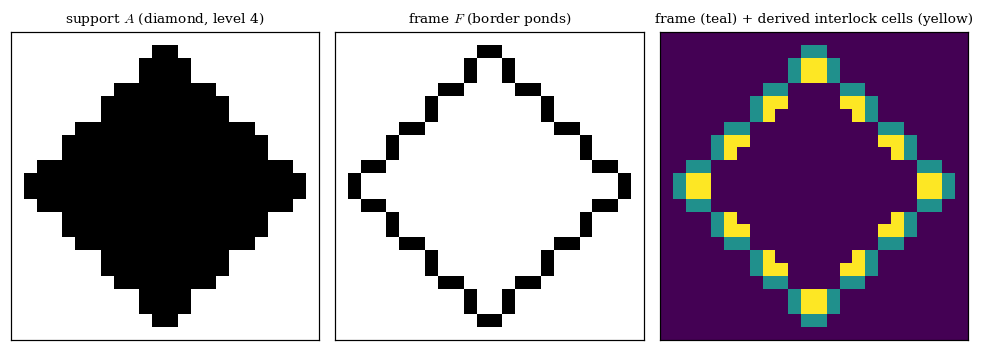

In [2]:
LEVEL_DEMO = 4
dia = diamond_scheme(LEVEL_DEMO)
dia_interlock = derive_interlock(dia)

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
show_grid(axes[0], dia.support.astype(int), f"support $A$ (diamond, level {LEVEL_DEMO})")
show_grid(axes[1], dia.frame.astype(int), "frame $F$ (border ponds)")
combo = dia.frame.astype(int).copy()
for (i, j) in dia_interlock:
    combo[i, j] = 2
axes[2].imshow(combo, cmap="viridis", interpolation="nearest")
axes[2].set_xticks([]); axes[2].set_yticks([])
axes[2].set_title("frame (teal) + derived interlock cells (yellow)", fontsize=9)
plt.tight_layout(); plt.show()

## 2. The `TileScheme` abstraction

`gol_mosaics.tile_scheme` implements exactly the objects above:

* `TileScheme(name, level, support, frame, u, v)` — a frozen dataclass; construction
  asserts D4 symmetry, $F \subseteq A$, and a dead outer ring (so the toroidal
  wraparound in the SAT encoding stays inert).
* `derive_interlock(scheme)` — the generic morphological recipe of (S2), including the
  (S3) frame-consistency check on overlaps.
* `build_scheme_domain(scheme)` — reduces the scheme to the existing
  `tile_domain.Domain`: one boolean per free D4 orbit, forced orbits folded into
  constants. **From here on, the pre-existing SAT machinery works unchanged** —
  the CNF builder, the AllSAT enumerator, the packers all consume a `Domain`
  without caring where its geometry came from.
* `check_frame_mosaic(scheme)` — hypothesis (H), verified against the independent
  `gol_mosaics.life` implementation.
* `assemble(scheme, index_grid, tiles)` — pastes tiles onto the $a\,\vec u + b\,\vec v$
  lattice, asserting overlap consistency cell by cell.

The paper-pinned diamond modules (`tile_domain`, `sat_search`) are deliberately left
untouched; the abstraction is built *next to* them, not through them.

## 3. Validation: the diamond as a scheme instance

An abstraction of a formally verified pipeline earns trust by reproducing it
**exactly**. The diamond scheme uses basis vectors
$\vec u = (3L, 3L)$, $\vec v = (3L, -3L)$ (the interlocking half-tile lattice). The
generic derivation must return precisely the interlock cells of
`tile_domain.derive_dead_edges_full` — the ones proven correct in the paper and
underlying the shipped censuses (7, 85, 2632, 332,321, 108,492,376 tiles for levels
3–7) — and the free-orbit counts must match the design-time table.

In [3]:
for L in (2, 3, 4, 5, 6):
    s = diamond_scheme(L)
    match = derive_interlock(s) == tile_domain.derive_dead_edges_full(L)
    dom = build_scheme_domain(s)
    expected = tile_domain.EXPECTED_FREE_ORBITS.get(L)
    print(f"level {L}: interlock reproduced exactly: {match};  "
          f"free orbits {len(dom.free_reps)}"
          + (f" (expected {expected})" if expected else "")
          + f";  (H) holds: {check_frame_mosaic(s)}")

level 2: interlock reproduced exactly: True;  free orbits 3;  (H) holds: True
level 3: interlock reproduced exactly: True;  free orbits 10 (expected 10);  (H) holds: True
level 4: interlock reproduced exactly: True;  free orbits 22 (expected 22);  (H) holds: True
level 5: interlock reproduced exactly: True;  free orbits 38 (expected 38);  (H) holds: True
level 6: interlock reproduced exactly: True;  free orbits 59 (expected 59);  (H) holds: True


Five levels, byte-exact agreement. The abstraction *is* the diamond pipeline when
instantiated with the diamond geometry.

## 4. A new instance: pond-frame squares

Now for a genuinely new family: **axis-aligned square tiles**, glued — like the
diamonds — by ponds.

### 4.1 A first idea, and why it fails

The obvious frame would be the border of the dense pond lattice used inside diamonds,
where adjacent ponds *share* their 1-cell-wide edges. But straight shared-edge pond
chains are **not** still lifes: the dead cell midway between two shared ponds sees
exactly three live neighbours and gives birth. The diamond gets away with dense pond
packing because its frame chains always run **diagonally** (offset $(3,3)$), where the
shared cells see a different, stable configuration. This is a nice hidden reason for
the diamond shape — and the first real design constraint for any axis-aligned scheme.

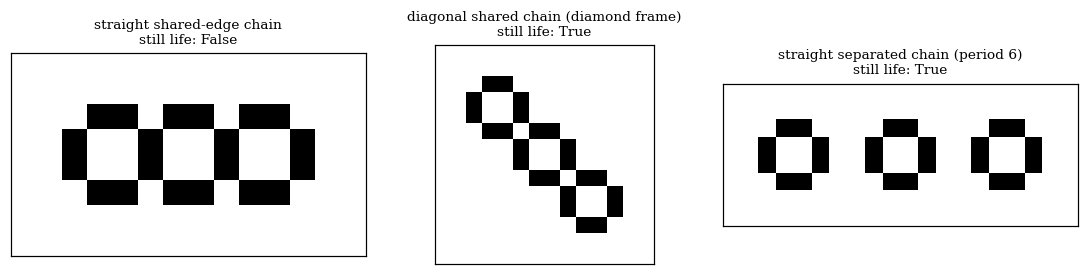

In [4]:
pond = tile_domain.pond_pattern()
chain = np.pad(np.hstack([pond[:, :-1], pond[:, :-1], pond]), 2)
diag = np.zeros((14, 14), dtype=np.uint8)
for k in range(3):
    diag[2 + 3*k:6 + 3*k, 2 + 3*k:6 + 3*k] |= pond.astype(np.uint8)
sep = np.zeros((8, 20), dtype=np.uint8)
for k in range(3):
    sep[2:6, 2 + 6*k:6 + 6*k] = pond

fig, axes = plt.subplots(1, 3, figsize=(10, 2.6))
for ax, (g, name) in zip(axes, [
        (chain, "straight shared-edge chain"),
        (diag, "diagonal shared chain (diamond frame)"),
        (sep, "straight separated chain (period 6)")]):
    show_grid(ax, g, f"{name}\nstill life: {is_still_life(g)}")
plt.tight_layout(); plt.show()

### 4.2 The design that works

So the square frame must keep its ponds **separated**: a ring of ponds on the period-6
pond grid (2 dead cells between consecutive ponds), around a square tile of size
$n = 6L$ with a dead outer ring. For the lattice, we place tiles at pitch
$6(L-1)$ — six cells *less* than the tile — so that **adjacent tiles share their border
pond band**, the axis-aligned analogue of neighbouring diamonds sharing their edge
ponds. Overlapping supports are exactly what condition (S3) is for: the shared band is
frame in *both* tiles (forced identically), and every free cell in the overlap is swept
into the interlock set by the generic derivation.

`pond_square_scheme(level)` builds this. Here is level 4, with its automatically
derived interlock cells:

n = 24, pitch = 18, |interlock| = 288, free orbits = 15


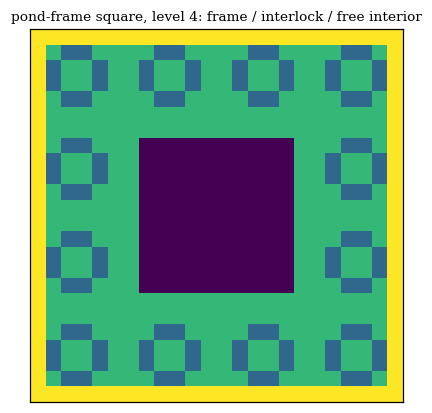

In [5]:
sq = pond_square_scheme(4)
il = derive_interlock(sq)
dom = build_scheme_domain(sq)
print(f"n = {sq.n}, pitch = {sq.u[0]}, |interlock| = {len(il)}, "
      f"free orbits = {len(dom.free_reps)}")

canvas = np.zeros((sq.n, sq.n), dtype=int)
canvas[~sq.support] = 3           # dead outer ring
canvas[sq.frame] = 1              # frame ponds
for (i, j) in il:
    canvas[i, j] = 2              # interlock cells
fig, ax = plt.subplots(figsize=(4.4, 4.4))
ax.imshow(canvas, cmap="viridis", interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("pond-frame square, level 4: frame / interlock / free interior",
             fontsize=9)
plt.show()

The derivation forces the whole shared band and its collar dead, leaving a free
interior square of $(6L-14)^2$ cells (level 3: $4\times4$, level 4: $10\times10$,
level 5: $16\times16$, …). The scheme degenerates gracefully: at level 2 everything is
forced and the family has exactly one tile — its frame.

### 4.3 Hypothesis (H)

The union of all frames is a subgrid of *separated* ponds — every pond isolated by at
least two dead cells — so (H) should hold at every level. Checked against the
independent Life implementation:

level 2: frame-only mosaic is a still life: True
level 3: frame-only mosaic is a still life: True
level 4: frame-only mosaic is a still life: True
level 5: frame-only mosaic is a still life: True


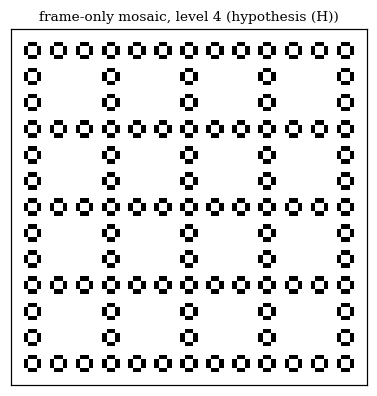

In [6]:
for L in (2, 3, 4, 5):
    print(f"level {L}: frame-only mosaic is a still life: "
          f"{check_frame_mosaic(pond_square_scheme(L), extent=5)}")

fig, ax = plt.subplots(figsize=(4.2, 4.2))
show_grid(ax, frame_mosaic(pond_square_scheme(4), extent=4),
          "frame-only mosaic, level 4 (hypothesis (H))")
plt.show()

## 5. Enumerating the new family

Because `build_scheme_domain` produces an ordinary `Domain`, tile enumeration is the
same one-variable-per-free-orbit SAT problem as for diamonds: CaDiCaL enumerates all
models under blocking clauses. For the small levels we can also brute-force all
$2^{\#\text{orbits}}$ assignments as an independent ground truth.

In [7]:
from itertools import product
from gol_mosaics.sat_search import rule_violations

census = {}
for L in (2, 3, 4, 5):
    s = pond_square_scheme(L)
    t0 = time.time()
    tiles = enumerate_scheme_tiles(s)
    census[L] = tiles
    k = len(build_scheme_domain(s).free_reps)
    line = (f"level {L}: {k:3d} free orbits -> {len(tiles):6,d} tiles "
            f"in {time.time()-t0:5.2f}s")
    if k and k <= 15:  # brute-force cross-check where feasible
        bits = np.array(list(product((0, 1), repeat=k)), dtype=np.uint8)
        grids = build_scheme_domain(s).expand_many(bits)
        n_bf = int((rule_violations(grids) == 0).sum())
        line += f"   [brute force over 2^{k}: {n_bf} -> "
        line += "match]" if n_bf == len(tiles) else "MISMATCH]"
    print(line)

level 2:   0 free orbits ->      1 tiles in  0.02s
level 3:   3 free orbits ->      3 tiles in  0.05s   [brute force over 2^3: 3 -> match]


level 4:  15 free orbits ->     65 tiles in  0.07s   [brute force over 2^15: 65 -> match]


level 5:  36 free orbits -> 10,398 tiles in  0.32s


The census of the pond-frame square family starts **1, 3, 65, 10,398** (levels
2–5) — a brand-new integer sequence, sibling to the diamond's 1, 2, 7, 85, 2632,
332,321, 108,492,376. Level 6 (66 free orbits) is too large to enumerate naively in
16 GB of RAM, but a cube-and-conquer count — 256 cubes over the first eight orbit
variables, eight workers, the same strategy that produced the level-7 diamond census —
finishes in about seven minutes on an M4 and gives exactly

$$\bigl|\text{pond-square level 6}\bigr| \;=\; 19{,}287{,}185 \text{ tiles},$$

with tile populations ranging from 160 (the bare frame) to 412 live cells.
An independent ApproxMC $(\varepsilon{=}0.5,\ \delta{=}0.1)$ estimate of the same CNF
gives 20,709,376 — within its guarantee band, cross-validating the count. The gated
cell below reproduces the exact number.

In [8]:
RUN_LEVEL_6 = False  # ~7 minutes on 8 cores, bounded memory
if RUN_LEVEL_6:
    from multiprocessing import Pool
    from gol_mosaics.sat_search import cube_units, enumerate_all

    enc6 = tile_scheme.build_scheme_cnf(pond_square_scheme(6))

    def count_cube(cube):
        return len(enumerate_all(enc6, extra_units=cube_units(cube, 8)))

    t0 = time.time()
    with Pool(8) as pool:
        total = sum(pool.imap_unordered(count_cube, range(256)))
    print(f"level 6: {total:,} tiles in {time.time()-t0:.0f}s")

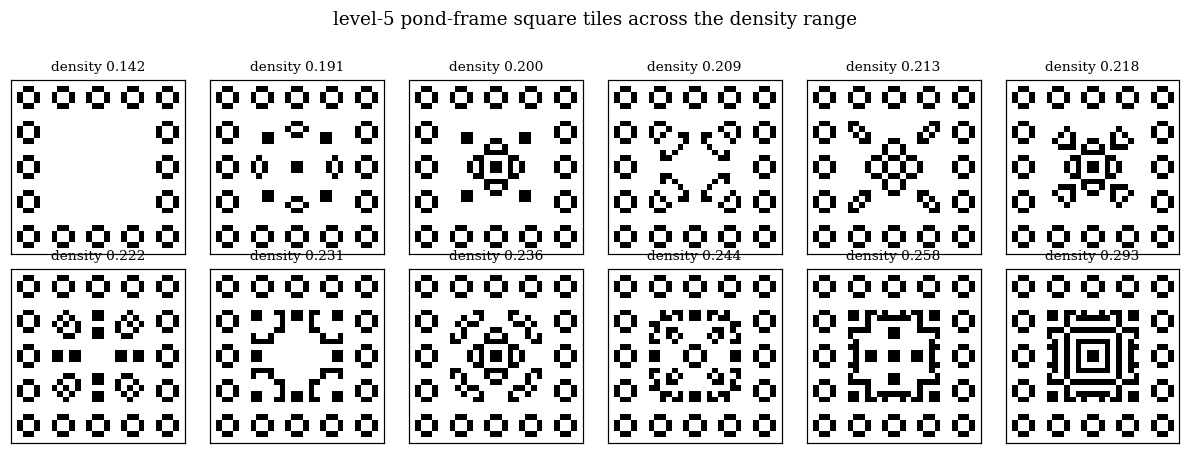

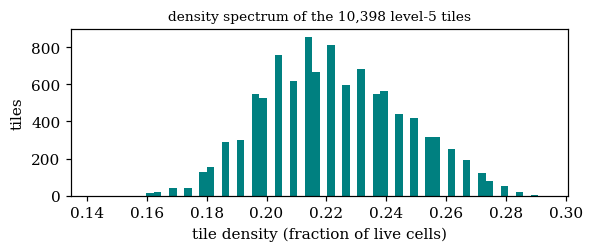

In [9]:
tiles5 = census[5]
dens5 = tiles5.mean(axis=(1, 2))
order = np.argsort(dens5)
picks = order[np.linspace(0, len(order) - 1, 12).astype(int)]
fig, axes = plt.subplots(2, 6, figsize=(11, 4))
for ax, idx in zip(axes.ravel(), picks):
    show_grid(ax, tiles5[idx], f"density {dens5[idx]:.3f}")
fig.suptitle("level-5 pond-frame square tiles across the density range", y=1.02)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5.5, 2.4))
ax.hist(dens5, bins=60, color="teal")
ax.set_xlabel("tile density (fraction of live cells)")
ax.set_ylabel("tiles")
ax.set_title(f"density spectrum of the {len(tiles5):,} level-5 tiles", fontsize=9)
plt.tight_layout(); plt.show()

A healthy density spectrum is exactly what greyscale emulation needs: each grey
value will be matched to the nearest tile density.

## 6. Composability in action

First the positive control: assemble mosaics of *randomly chosen* tiles — the hardest
case for composability, since no care whatsoever is taken about which tiles sit next to
each other — and verify global stability with the independent Life implementation.
Then the negative control: re-enumerate tiles **without** the interlock forcings.
Each such tile is a perfect still life in isolation, yet mosaics of them break — so the
interlock cells are necessary, and our stability check is capable of failing.

random 6x6 level-5 mosaic (154x154 cells): global still life = True


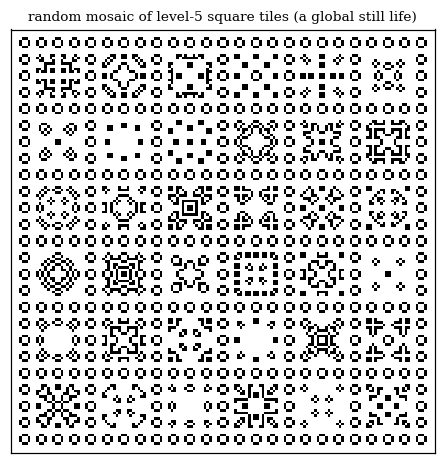

In [10]:
rng = np.random.default_rng(0)
sq5 = pond_square_scheme(5)
mosaic = assemble(sq5, rng.integers(0, len(tiles5), size=(6, 6)), tiles5)
print(f"random 6x6 level-5 mosaic ({mosaic.shape[0]}x{mosaic.shape[1]} cells): "
      f"global still life = {is_still_life(mosaic)}")
fig, ax = plt.subplots(figsize=(5, 5))
show_grid(ax, mosaic, "random mosaic of level-5 square tiles (a global still life)")
plt.show()

tiles without interlock forcings: 1254 (vs 65 with)
a violator in isolation is a still life: True
found an unstable mosaic of interlock-free tiles: True


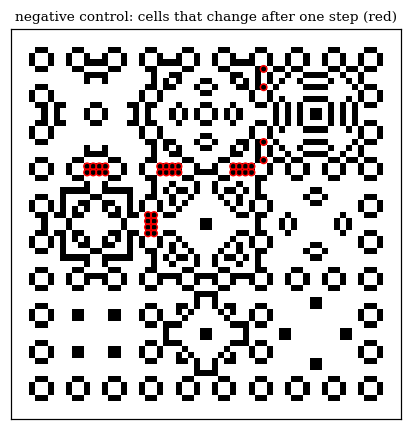

In [11]:
sq4 = pond_square_scheme(4)
loose = enumerate_scheme_tiles(sq4, interlock=set())  # negative control
print(f"tiles without interlock forcings: {len(loose)} "
      f"(vs {len(census[4])} with)")
tile = loose[-1]
print(f"a violator in isolation is a still life: "
      f"{is_still_life(np.pad(tile, sq4.n))}")

# Without the interlock forcings, tiles can DISAGREE on shared cells, so the
# strict assemble() rightly rejects most mixes (`assemble` raises). To see the
# dynamics we resolve overlaps by the union of live cells — one natural
# reading of such an ill-defined tiling — and step it once.
def union_assemble(scheme, index_grid, tiles):
    n, p = scheme.n, scheme.u[0]
    K = index_grid.shape[0]
    G = np.zeros((2 + (K - 1) * p + n + 2,) * 2, dtype=np.uint8)
    for a in range(K):
        for b in range(K):
            blk = G[2 + a*p:2 + a*p + n, 2 + b*p:2 + b*p + n]
            np.maximum(blk, tiles[index_grid[a, b]], out=blk)
    return G

m_bad = None
for _ in range(200):
    m = union_assemble(sq4, rng.integers(0, len(loose), size=(3, 3)), loose)
    if not is_still_life(m):
        m_bad = m
        break
assert m_bad is not None, "expected some interlock-free mix to destabilise"
print("found an unstable mosaic of interlock-free tiles: True")
diff = (life_step(m_bad) != m_bad)
fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.imshow(m_bad, cmap="binary", interpolation="nearest")
yy, xx = np.where(diff)
ax.scatter(xx, yy, s=18, facecolors="none", edgecolors="red", linewidths=1.0)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("negative control: cells that change after one step (red)",
             fontsize=9)
plt.show()

## 7. Emulating a greyscale picture

The image pipeline for an axis-aligned scheme is *simpler* than for diamonds: no 45°
rotation, no interleaved diagonal grids. Downscale the picture to $K\times K$ grey
values, map each value to the tile of nearest (normalised) density — dark pixels get
dense tiles — and `assemble`. Ties are broken randomly for texture.

In [12]:
def greyscale_to_mosaic(img_path, scheme, tiles, K=36, seed=0,
                        low=0.02, high=0.98):
    rng = np.random.default_rng(seed)
    img = Image.open(img_path).convert("L")
    side = min(img.size)
    img = img.crop(((img.width - side) // 2, (img.height - side) // 2,
                    (img.width + side) // 2, (img.height + side) // 2))
    values = np.asarray(img.resize((K, K), Image.LANCZOS), dtype=float) / 255.0
    lo, hi = np.quantile(values, [low, high])
    values = np.clip((values - lo) / (hi - lo), 0, 1)

    dens = tiles.mean(axis=(1, 2))
    dnorm = (dens - dens.min()) / (dens.max() - dens.min())
    targets = 1.0 - values          # dark pixel -> dense tile
    dist = np.abs(dnorm[None, None, :] - targets[:, :, None])
    best = dist.min(axis=2, keepdims=True)
    index_grid = np.zeros((K, K), dtype=int)
    for a in range(K):
        for b in range(K):
            ties = np.flatnonzero(dist[a, b] == best[a, b, 0])
            index_grid[a, b] = rng.choice(ties)
    return values, assemble(scheme, index_grid, tiles)

IMG = Path.cwd().parent / "input" / "images" / "john-original.png"
values, big = greyscale_to_mosaic(IMG, sq5, tiles5, K=36)
print(f"mosaic: {big.shape[0]}x{big.shape[1]} cells, "
      f"{int(big.sum()):,} live; global still life = {is_still_life(big)}")

mosaic: 874x874 cells, 184,604 live; global still life = True


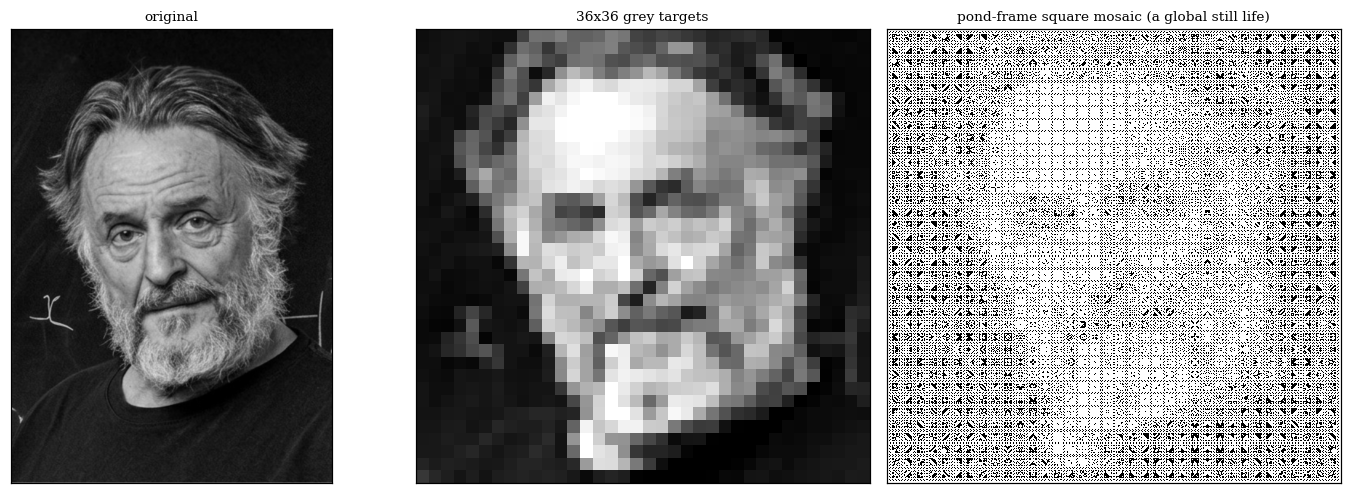

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
axes[0].imshow(Image.open(IMG).convert("L"), cmap="gray")
axes[0].set_title("original", fontsize=9)
axes[1].imshow(values, cmap="gray", interpolation="nearest")
axes[1].set_title("36x36 grey targets", fontsize=9)
axes[2].imshow(big, cmap="binary", interpolation="nearest")
axes[2].set_title("pond-frame square mosaic (a global still life)", fontsize=9)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

Load this into Golly and run it: nothing moves. Every choice made along the way —
which of the 10,398 tiles sits where — is covered by the composition theorem, so the
verification is expected to pass **by proof**, not by luck; the `is_still_life` call is
a redundant independent check in the spirit of the rest of this repository.

## 8. The scheme zoo

The abstraction makes other families one constructor away. The degenerate baseline —
square tiles with an **empty frame** behind a dead moat, where (H) holds vacuously and
tiles never interact — takes three lines. It shows both ends of the spectrum: the
pond-frame schemes buy visible linkage at the price of forced structure; the dead-moat
scheme buys maximal interior freedom at the price of visual isolation.

dead-moat level 2: interlock = set() (none needed)
tiles: 15 (every 12x12 D4-symmetric still life in an 8x8 box)
random mosaic still life: True


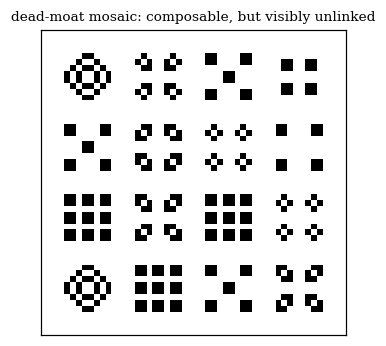

In [14]:
moat = dead_moat_square_scheme(2)
print(f"dead-moat level 2: interlock = {derive_interlock(moat)} (none needed)")
mt = enumerate_scheme_tiles(moat)
print(f"tiles: {len(mt)} (every 12x12 D4-symmetric still life in an 8x8 box)")
m = assemble(moat, rng.integers(0, len(mt), (4, 4)), mt)
print(f"random mosaic still life: {is_still_life(m)}")
fig, ax = plt.subplots(figsize=(3.6, 3.6))
show_grid(ax, m, "dead-moat mosaic: composable, but visibly unlinked")
plt.show()

Directions the abstraction leaves open, roughly in order of interest:

* **Rectangular tiles on a brick (running-bond) lattice** — only the basis vectors
  change ($\vec u = (n, 0)$, $\vec v = (n/2, m)$); symmetry drops from D4 to D2, so the
  orbit machinery needs a group parameter, but nothing else does.
* **Other frame motifs** — any still-life border whose frame-only mosaic satisfies (H):
  rings of blocks, beehives, or longboats instead of ponds. Finding motifs that stay
  stable *and* leave a large free interior is a small search problem of its own.
* **Other rules** — `enumerate_scheme_tiles` already takes `birth`/`survival`;
  the square scheme under HighLife (B36/S23) only requires re-checking (H), since the
  separated pond ring contains no cell with six live neighbours.
* **Census growth** — the square sequence 1, 3, 65, 10,398, 19,287,185 (levels 2–6)
  against the diamond's 1, 2, 7, 85, 2632, 332,321: two members of what is presumably a
  whole zoo of scheme censuses, none of them in the OEIS. The square family grows
  *faster* per level (×160, ×1855 for the last steps vs the diamond's ×31, ×126),
  simply because its free-orbit count grows faster (3, 15, 36, 66 vs the diamond's
  10, 22, 38, 59 at the same tile size).

**Summary.** The diamond was never essential. The mosaic framework rests on three
scheme-level conditions — a lattice, a consistently forced frame with derived interlock
cells, and one global stability check (H) — and any geometry satisfying them inherits
the full pipeline: SAT enumeration, density-based greyscale matching, and
provably-still mosaics. The pond-frame square family is the first new citizen, from
axioms to a verified picture.